In [1]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = (parent_dir + '/dfs/')
print(data_path)

c:\Users\dinshi\My Drive\SFARI projects\Data & Code\SSP Manuscript/dfs/


In [2]:
# Load the subject list from previous analyses:
subject_ids = pd.read_csv(data_path+'\SSP_participants_3nights.csv')
len(subject_ids)

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\dinshi\AppData\Local\Temp\ipykernel_20744\3619565489.py:2: SyntaxWarning: invalid escape sequence '\S'
  subject_ids = pd.read_csv(data_path+'\SSP_participants_3nights.csv')


136

In [3]:
# Load questionnaires data:
Quest_data = pd.read_csv(data_path+'df_questionnaires.csv')

# Load Dreem and Pops data:
df_dreem = pd.read_csv(data_path+'df_dreem_clean.csv')
df_yasa = pd.read_csv(data_path+'df_yasa_clean.csv')

print(len(Quest_data), len(df_dreem), len(df_yasa))

200 2408 2271


In [4]:
# Merge Dreem and Yasa data by subject ID and date:
df_dreem['date'] = pd.to_datetime(df_dreem['date'])
df_yasa['date'] = pd.to_datetime(df_yasa['date'])

# Add device names to column names except for 'SPID' and 'date':
exclude_columns = ['SPID', 'date']

# Add suffix to all other column names
df_dreem = df_dreem.rename(columns={col: f"{col}_dreem" for col in df_dreem.columns if col not in exclude_columns})
df_yasa = df_yasa.rename(columns={col: f"{col}_yasa" for col in df_yasa.columns if col not in exclude_columns})

# Merge the DataFrames on 'SPID' and 'date'
merged_df = pd.merge(df_dreem, df_yasa, on=['SPID', 'date'], how='inner')

print(len(merged_df))

2202


In [5]:
# Group by subject and filter out those with less than 3 nights/rows
subject_night_counts = merged_df['SPID'].value_counts()
subjects_to_keep = subject_night_counts[subject_night_counts >= 3].index

# Extract DreemPops_data containing only the subjects with 3 or more nights/rows with both device recordings:
DreemYasa_3nights = merged_df[merged_df['SPID'].isin(subjects_to_keep)]
print(len(DreemYasa_3nights))

# Extract overlapping data with the subjects used in previous analyses:
DreemYasa_3nights = DreemYasa_3nights[DreemYasa_3nights['SPID'].isin(subject_ids['SPID'])]
print(len(DreemYasa_3nights))

# Count number of ASD and Sib subjects in this dataset:
DreemYasa_3nights_ASD = DreemYasa_3nights[DreemYasa_3nights['user_type_dreem'] == 'ASD']
DreemYasa_3nights_Sib = DreemYasa_3nights[DreemYasa_3nights['user_type_dreem'] == 'NASD']

print(len(DreemYasa_3nights_ASD['SPID'].unique()))
print(len(DreemYasa_3nights_Sib['SPID'].unique()))

2187
1728
69
67


Organize the data to allow correlation between sleep measures and questionnaire scores:

In [6]:
# Compute the average per subject of selected sleep measures:

DreemYasa_bysub = DreemYasa_3nights[['SPID','TST_dreem', 'WASO_dreem', 'SOL_dreem', 
                                     'SO_FromMidNight_dreem', 'FA_FromMidNight_dreem', 'WASO_yasa', 'TST_yasa',
                                     'SOL_yasa', 'SO_FromMidNight_yasa','FA_FromMidNight_yasa']].groupby('SPID').mean()

print(len(DreemYasa_bysub))

136


In [7]:
# Merge sleep measures data with questionnaire data:
Combined_data_bysub = DreemYasa_bysub.merge(Quest_data, on='SPID', how='inner')

print(len(Combined_data_bysub))

136


Create correlation and p-value matrices:

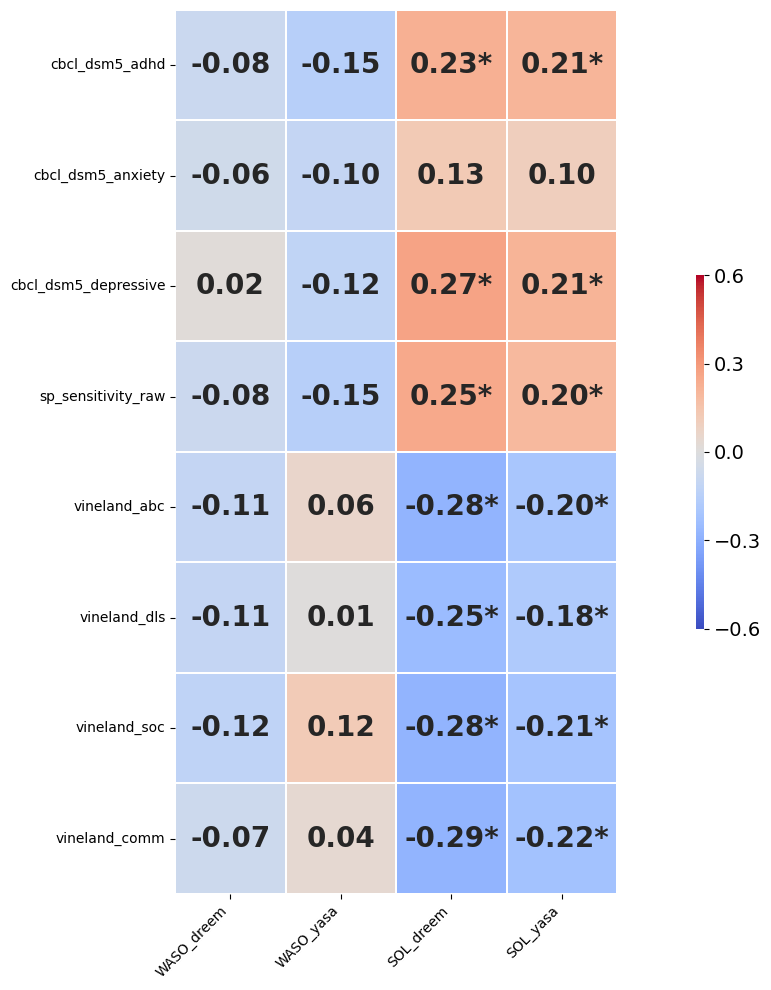

In [8]:
# Select measures to examine:

y_measures = ['WASO_dreem','WASO_yasa', 'SOL_dreem', 'SOL_yasa']


x_measures = ['cbcl_dsm5_adhd', 'cbcl_dsm5_anxiety', 'cbcl_dsm5_depressive', 
       'sp_sensitivity_raw', 'vineland_abc', 'vineland_dls', 'vineland_soc',
       'vineland_comm']

# Create two matrices to hold the correlation coefficients and their p values:
corr_matrix = pd.DataFrame(index=x_measures, columns=y_measures, dtype=float)
p_matrix = pd.DataFrame(index=x_measures, columns=y_measures, dtype=float)

# Now loop through pairs of variables and compute correlation and p-value
for x in x_measures:
       for y in y_measures:
              # Create a new data frame while removing everything except for x and y variables
              xy_data = Combined_data_bysub[[x, y]].dropna()
              corr, p_value = pearsonr(xy_data[x], xy_data[y])                    
              corr_matrix.loc[x, y] = corr
              p_matrix.loc[x, y] = p_value


# Create figure with results:
plt.figure(figsize=(16, 10))

# Create a mask for significant correlations - define p value
sig_mask = p_matrix <= 0.05

# Create annotation array
annot = np.empty_like(corr_matrix, dtype=object)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        annot[i,j] = f"{corr_matrix.iloc[i,j]:.2f}"
        if sig_mask.iloc[i,j]:
            annot[i,j] += '*'

# Use function from Seaborn package to create color matrix:
ax = sns.heatmap(corr_matrix, annot=annot, fmt='', cmap='coolwarm', vmin=-0.6, vmax=0.6, center=0, 
            linewidths=.1,annot_kws={'size': 20, 'weight':'bold'}, 
                    square=True, cbar_kws={'shrink': 0.4, 'aspect': 40} )

# Properties for color bar on right of figure
cbar = ax.collections[0].colorbar
# cbar.set_label('Correlation', fontsize=16)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks([-0.6, -0.3, 0, 0.3, 0.6])

plt.xticks(rotation=45, ha='right',fontsize = 10)
plt.yticks(rotation=0,fontsize = 10)
plt.tight_layout()
# plt.savefig(f'/mnt/home/mhacohen/ceph/weekly_report/{title}.png')
plt.show()
